# 01 — Dữ liệu và Train/Validation Split
Theo dõi việc đọc dữ liệu, tách X/y, log target và chia Development/Hold-out Validation.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt
cwd=Path.cwd(); ROOT=cwd.parent if cwd.name.lower()=="notebooks" else cwd
SRC_DIR=ROOT/"src"
if str(SRC_DIR) not in sys.path: sys.path.append(str(SRC_DIR))
DATA_DIR=ROOT/"data"; EXPS_DIR=ROOT/"exps"; MODELS_DIR=ROOT/"models"/"sklearn"; SUBMISSIONS_DIR=ROOT/"submissions"
print("ROOT:",ROOT)
print("train.csv:",(DATA_DIR/"train.csv").exists())

ROOT: D:\house_price
train.csv: True


In [2]:
from sklearn.model_selection import train_test_split
train=pd.read_csv(DATA_DIR/"train.csv")
print("Shape:",train.shape)
display(train.head())

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
missing=train.isna().sum().sort_values(ascending=False)
display(missing[missing>0].to_frame("missing_count").head(25))

,missing_count
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


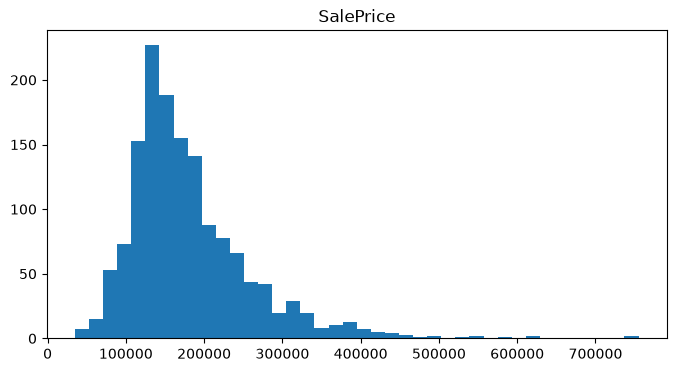

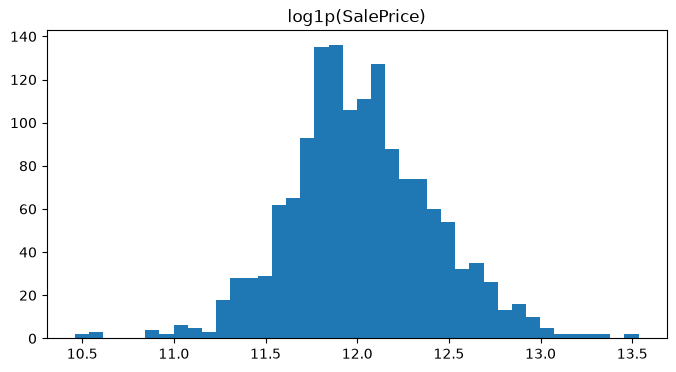

In [4]:
print(train["SalePrice"].describe())
plt.figure(figsize=(8,4)); plt.hist(train["SalePrice"],bins=40); plt.title("SalePrice"); plt.show()
y_log=np.log1p(train["SalePrice"])
plt.figure(figsize=(8,4)); plt.hist(y_log,bins=40); plt.title("log1p(SalePrice)"); plt.show()

In [5]:
X=train.drop(columns=["SalePrice"]); y=train["SalePrice"]
X_dev,X_valid,y_dev,y_valid=train_test_split(X,y,test_size=0.2,random_state=42)
print("Development:",X_dev.shape)
print("Validation :",X_valid.shape)

Development: (1168, 80)
Validation : (292, 80)


Development dùng cho 5-Fold CV và experiments. Hold-out validation được giữ riêng để kiểm tra cấu hình cuối.